# Entregable 3 — Modelado de la Solución
## Predicción del Valor de Mercado de Jugadores de Fútbol

**Ciencia de Datos Aplicada — ITBA** · Octavio Argonz & Matías Sola · 2026

---
### Qué resuelve este notebook
Estimar el **valor de mercado de un jugador dentro de 1 año** (próxima ventana), usando solo
información disponible al momento de la predicción. El producto final no es un número suelto
sino un **rango de valor calibrado** (ej. "€20M – €34M") pensado para apoyar negociaciones, más
un **ranking de oportunidades** (quién se va a revalorizar o devaluar).

### Decisiones de diseño (y por qué)
1. **Predecimos el _crecimiento_ del valor, no el nivel.** El valor es muy persistente, así que
   predecir el nivel da un R² alto pero engañoso (el modelo solo copia el valor actual). Al
   predecir la variación logarítmica obligamos al modelo a usar edad, rendimiento, liga, club,
   contrato y transferencias. Reconstruimos el valor con: `valor_T+1 = expm1(log(1+valor_T) + crecimiento)`.
2. **Horizonte anclado a 12 meses.** Tomamos el valor vigente al **30 de junio** (cierre de
   temporada europea) de cada año, y el target al 30 de junio del año siguiente. Todas las
   predicciones son a ~1 año, comparables entre sí.
3. **Aprendemos también las caídas.** Los jugadores que "desaparecen" (se retiran, lesión grave,
   bajan de categoría) antes se descartaban → sesgo de supervivencia. Ahora los incluimos como
   devaluaciones fuertes para que el modelo anticipe declives. Probamos varias intensidades de
   caída y elegimos la mejor.
4. **Intervalos calibrados.** Usamos regresión cuantil + calibración conformal para que el rango
   P10–P90 contenga al valor real el ~80% de las veces (preciso y confiable, no solo ancho).

## 1. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings, json, sys, subprocess

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib

try:
    import xgboost as xgb
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'xgboost'])
    import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
print("Librerías cargadas. xgboost", xgb.__version__)

Librerías cargadas. xgboost 3.2.0


## 2. Carga de datos

Detección automática de ruta (Colab con Drive montado o ejecución local). Cargamos cinco tablas:
`players`, `appearances`, `player_valuations`, `competitions` y `transfers`.

In [2]:
try:
    import google.colab  # type: ignore
    from google.colab import drive  # type: ignore
    if not Path('/content/drive/MyDrive').exists():
        drive.mount('/content/drive')
except ImportError:
    pass

CAND = [Path('/content/drive/MyDrive/futbol-valuacion/data/raw/'),
        Path('/content/drive/MyDrive/ciencia de datos/futbol-valuacion/data/raw/'),
        Path('../data/raw/'), Path('./data/raw/'), Path('data/raw/')]
DATA_PATH = next((c for c in CAND if (c / 'players.csv').exists()), None)
if DATA_PATH is None and Path('/content/drive/MyDrive').exists():
    m = list(Path('/content/drive/MyDrive').glob('**/data/raw/players.csv'))
    if m: DATA_PATH = m[0].parent
if DATA_PATH is None:
    raise FileNotFoundError('No se encontró players.csv en data/raw/.')
DATA_PATH = str(DATA_PATH).rstrip('/') + '/'
print('DATA_PATH:', DATA_PATH)

players = pd.read_csv(DATA_PATH + 'players.csv')
appearances = pd.read_csv(DATA_PATH + 'appearances.csv',
    usecols=['player_id', 'game_id', 'player_club_id', 'date', 'competition_id',
             'goals', 'assists', 'minutes_played', 'yellow_cards'])
valuations = pd.read_csv(DATA_PATH + 'player_valuations.csv')
competitions = pd.read_csv(DATA_PATH + 'competitions.csv', usecols=['competition_id', 'type'])
transfers = pd.read_csv(DATA_PATH + 'transfers.csv', usecols=['player_id', 'transfer_date', 'transfer_fee'])

for d, c in [(appearances, 'date'), (valuations, 'date'), (transfers, 'transfer_date')]:
    d[c] = pd.to_datetime(d[c], errors='coerce')
players['date_of_birth'] = pd.to_datetime(players['date_of_birth'], errors='coerce')
players['contract_year'] = pd.to_datetime(players['contract_expiration_date'], errors='coerce').dt.year
appearances['anio'] = appearances['date'].dt.year
valuations['anio'] = valuations['date'].dt.year
transfers['anio'] = transfers['transfer_date'].dt.year

print(f"players {players.shape} | appearances {appearances.shape} | valuations {valuations.shape} | transfers {transfers.shape}")

DATA_PATH: ..\data\raw/


players (47702, 27) | appearances (1862208, 10) | valuations (616377, 7) | transfers (157186, 4)


## 3. Construcción del dataset jugador-año

### 3.1 Horizonte anclado: valor al 30 de junio de cada año

Para cada jugador y cada año T tomamos su **valuación vigente al 30/06/T** (la última con fecha
≤ 30/06/T). Exigimos que sea "fresca" (≤ 15 meses de antigüedad) para no arrastrar valores viejos.
Usamos `merge_asof`, que para cada fecha de corte busca hacia atrás la valuación más reciente.

In [3]:
YEARS = list(range(2004, 2026))
pids = valuations['player_id'].unique()
grid = pd.MultiIndex.from_product([pids, YEARS], names=['player_id', 'T']).to_frame(index=False)
grid['cutoff'] = pd.to_datetime(dict(year=grid['T'], month=6, day=30))
grid = grid.sort_values('cutoff')

vs = valuations.dropna(subset=['market_value_in_eur']).sort_values('date')
va = pd.merge_asof(
    grid, vs[['player_id', 'date', 'market_value_in_eur', 'player_club_domestic_competition_id']],
    left_on='cutoff', right_on='date', by='player_id', direction='backward'
).rename(columns={'market_value_in_eur': 'valor', 'player_club_domestic_competition_id': 'liga'})

va['gap_dias'] = (va['cutoff'] - va['date']).dt.days
va['fresh'] = va['gap_dias'] <= 460          # valuación vigente y no añeja
va = va.sort_values(['player_id', 'T'])
va['valor_next'] = va.groupby('player_id')['valor'].shift(-1)
va['fresh_next'] = va.groupby('player_id')['fresh'].shift(-1)
va['pico_prev'] = va.groupby('player_id')['valor'].cummax()   # máximo histórico hasta T (sin leakage)
print('Grilla jugador-año:', va.shape, '| con valor fresco:', f"{va['fresh'].mean():.1%}")

Grilla jugador-año: (865942, 11) | con valor fresco: 35.2%


### 3.2 Supervivientes y desaparecidos

- **Superviviente:** tiene valor fresco en T y en T+1 → target = valor real en T+1.
- **Desaparecido:** tiene valor fresco en T pero **no** en T+1 (dejó de ser valuado) y T+1 no es
  el borde de los datos. Antes se descartaban (sesgo de supervivencia); ahora les asignamos una
  **caída** (target = fracción del valor actual) para que el modelo aprenda a anticipar declives.
  La intensidad de la caída se elige empíricamente en la sección 3.7.

In [4]:
LAST_SEASON = 2025
base_fresh = va[va['fresh'] & (va['valor'] > 0)].copy()
supervivientes = base_fresh[base_fresh['fresh_next'] == True].copy()
supervivientes['mv_next'] = supervivientes['valor_next']
supervivientes['desaparece'] = 0
desaparecidos = base_fresh[(base_fresh['fresh_next'] != True) & (base_fresh['T'] < LAST_SEASON)].copy()
desaparecidos['desaparece'] = 1
print(f"Supervivientes: {len(supervivientes)} | Desaparecidos (antes descartados): {len(desaparecidos)}")

Supervivientes: 256780 | Desaparecidos (antes descartados): 30121


### 3.3 Rendimiento por año + promedios móviles (2 años)

Agregamos goles/asistencias/minutos/apariciones por jugador-año, separando competición de liga
de la **internacional/continental** (Champions, Europa, etc.). Agregamos además promedios
**rolling de 2 años** para suavizar el ruido de una sola temporada.

In [5]:
appearances = appearances.merge(competitions, on='competition_id', how='left')
appearances['es_inter'] = (appearances['type'] == 'international_cup').astype(int)
st = appearances.groupby(['player_id', 'anio']).agg(
    n_ap=('game_id', 'count'), goles=('goals', 'sum'), asist=('assists', 'sum'),
    minutos=('minutes_played', 'sum'), amarillas=('yellow_cards', 'sum'),
    ap_inter=('es_inter', 'sum')).reset_index().sort_values(['player_id', 'anio'])
for c in ['n_ap', 'goles', 'asist', 'minutos']:
    st[c + '_roll2'] = st.groupby('player_id')[c].transform(lambda s: s.rolling(2, min_periods=1).mean())
st['goles_por_partido'] = st['goles'] / st['n_ap']
st['asist_por_partido'] = st['asist'] / st['n_ap']
st['minutos_promedio'] = st['minutos'] / st['n_ap']
st['jugo_internacional'] = (st['ap_inter'] > 0).astype(int)
print('Stats por jugador-año:', st.shape)

# Club principal por (jugador, año): el club con más apariciones
club_principal = (appearances.groupby(['player_id', 'anio', 'player_club_id']).size()
                  .reset_index(name='n').sort_values('n')
                  .groupby(['player_id', 'anio']).tail(1)[['player_id', 'anio', 'player_club_id']])

Stats por jugador-año: (116024, 16)


### 3.4 Contexto: nivel de liga, nivel de club, inflación de mercado y transferencias

- **`nivel_liga`** = mediana de valuaciones de la liga en el año **T-1** (sin leakage).
- **`nivel_club`** = mediana de valor del plantel del club en el año T (fuerza del equipo).
- **`nivel_mercado`** = mediana global de valuaciones del año T, normalizada sobre 2020. Captura
  la inflación editorial del mercado (Transfermarkt subió los valores con los años).
- **Transferencias**: si el jugador fue transferido ese año y el monto del fee (de `transfers.csv`).

In [6]:
mediana_liga = (valuations.dropna(subset=['player_club_domestic_competition_id', 'market_value_in_eur'])
    .groupby(['player_club_domestic_competition_id', 'anio'])['market_value_in_eur'].median()
    .reset_index().rename(columns={'market_value_in_eur': 'nivel_liga',
        'player_club_domestic_competition_id': 'liga', 'anio': 'anio_nivel'}))

infl = valuations.groupby('anio')['market_value_in_eur'].median()
infl = (infl / infl.get(2020, infl.median())).reset_index().rename(
    columns={'market_value_in_eur': 'nivel_mercado', 'anio': 'T'})

trans_anio = transfers.groupby(['player_id', 'anio']).agg(fee=('transfer_fee', 'max')).reset_index()
trans_anio['transferido'] = 1

ENC = {'Goalkeeper': 1, 'Defender': 2, 'Centre-Back': 2, 'Left-Back': 2, 'Right-Back': 2, 'Defence': 2,
       'Midfielder': 3, 'Midfield': 3, 'Central Midfield': 3, 'Defensive Midfield': 3,
       'Attacking Midfield': 3, 'Left Midfield': 3, 'Right Midfield': 3,
       'Forward': 4, 'Centre-Forward': 4, 'Left Winger': 4, 'Right Winger': 4,
       'Second Striker': 4, 'Attack': 4}
print('Contexto de liga, club, mercado y transferencias preparado.')

Contexto de liga, club, mercado y transferencias preparado.


### 3.5 Ensamblado de features

Función que, dado un conjunto de filas jugador-año, le pega todas las variables y construye
el target de crecimiento. La usamos para las distintas variantes de caída.

In [7]:
def ensamblar(muestra):
    d = muestra.merge(st, left_on=['player_id', 'T'], right_on=['player_id', 'anio'], how='left').drop(columns=['anio'])
    d = d.merge(club_principal, left_on=['player_id', 'T'], right_on=['player_id', 'anio'], how='left').drop(columns=['anio'])
    nivel_club = d.groupby(['player_club_id', 'T'])['valor'].median().reset_index().rename(columns={'valor': 'nivel_club'})
    d = d.merge(nivel_club, on=['player_club_id', 'T'], how='left')
    d = d.merge(trans_anio, left_on=['player_id', 'T'], right_on=['player_id', 'anio'], how='left').drop(columns=['anio'])
    d['transferido'] = d['transferido'].fillna(0)
    d['fee'] = d['fee'].fillna(0)
    d['anio_nivel'] = d['T'] - 1
    d = d.merge(mediana_liga, on=['liga', 'anio_nivel'], how='left').drop(columns=['anio_nivel'])
    d = d.merge(infl, on='T', how='left')
    pf = players[['player_id', 'date_of_birth', 'position', 'sub_position', 'contract_year', 'height_in_cm', 'foot']]
    d = d.merge(pf, on='player_id', how='left')
    d['edad'] = d['T'] - d['date_of_birth'].dt.year
    d = d[(d['edad'] >= 15) & (d['edad'] <= 45)].copy()
    d['posicion_num'] = d['sub_position'].map(ENC)
    m = d['posicion_num'].isna(); d.loc[m, 'posicion_num'] = d.loc[m, 'position'].map(ENC)
    d['posicion_num'] = d['posicion_num'].fillna(3)
    for v, n in [(1, 'es_arquero'), (2, 'es_defensor'), (3, 'es_mediocampista'), (4, 'es_delantero')]:
        d[n] = (d['posicion_num'] == v).astype(int)
    d['contrato_restante'] = (d['contract_year'] - d['T']).clip(-1, 6)
    d['sin_dato_contrato'] = d['contract_year'].isna().astype(int)
    d['contrato_restante'] = d['contrato_restante'].fillna(1)
    d['height_in_cm'] = d['height_in_cm'].fillna(d['height_in_cm'].median())
    d['pie_zurdo'] = (d['foot'] == 'left').astype(int)
    d['pie_ambidiestro'] = (d['foot'] == 'both').astype(int)
    d['dist_al_pico'] = (d['valor'] / d['pico_prev']).clip(0, 1).fillna(1)
    d['ratio_fee'] = (d['fee'] / d['valor'].clip(lower=1)).clip(0, 10)
    d['flag_liga_top'] = d['liga'].isin(['GB1', 'ES1', 'IT1', 'DE1', 'FR1']).astype(int)
    d['edad2'] = d['edad'] ** 2
    d['log_valor'] = np.log1p(d['valor'])
    for c in ['n_ap', 'goles', 'asist', 'minutos', 'amarillas', 'ap_inter',
              'n_ap_roll2', 'goles_roll2', 'asist_roll2', 'minutos_roll2',
              'goles_por_partido', 'asist_por_partido', 'minutos_promedio', 'jugo_internacional']:
        if c in d: d[c] = d[c].fillna(0)
    d['log_level'] = np.log1p(d['mv_next'])
    d['log_growth'] = np.log1p(d['mv_next']) - np.log1p(d['valor'])
    return d[np.isfinite(d['log_growth'])].copy()

FEATURES = [
    # Perfil
    'edad', 'edad2', 'es_arquero', 'es_defensor', 'es_mediocampista', 'es_delantero',
    'height_in_cm', 'pie_zurdo', 'pie_ambidiestro', 'contrato_restante', 'sin_dato_contrato',
    # Rendimiento (año T)
    'n_ap', 'goles_por_partido', 'asist_por_partido', 'minutos_promedio', 'amarillas',
    # Rendimiento suavizado (2 años)
    'n_ap_roll2', 'goles_roll2', 'asist_roll2', 'minutos_roll2',
    # Internacional
    'jugo_internacional', 'ap_inter',
    # Mercado / contexto
    'log_valor', 'dist_al_pico', 'flag_liga_top', 'nivel_liga', 'nivel_club', 'nivel_mercado',
    # Transferencias
    'transferido', 'ratio_fee',
]
TARGET = 'log_growth'
print(f'{len(FEATURES)} features definidas.')

30 features definidas.


### 3.6 Helper de imputación y split temporal

Imputamos `nivel_liga`/`nivel_club` con la mediana **de train** (sin mirar el test).
Split: train ≤ 2022, test ≥ 2023.

In [8]:
def split_xy(d):
    tr = d[d['T'] <= 2022].copy()
    te = d[d['T'] >= 2023].copy()
    for col in ['nivel_liga', 'nivel_club']:
        med = tr[col].median()
        tr[col] = tr[col].fillna(med); te[col] = te[col].fillna(med)
    return tr, te

### 3.7 Elección de la intensidad de caída (variantes de desaparición)

Probamos tres escenarios para los jugadores que desaparecen y los comparamos **sobre el mismo
test de supervivientes** (los únicos con valor real verificable). También medimos el *recall de
declives*: de los jugadores que efectivamente desaparecieron en test, qué fracción el modelo
predice con crecimiento negativo. Elegimos la variante con mejor MAE en supervivientes.

In [9]:
def construir(devalua):
    """devalua=None → solo supervivientes; float → desaparecidos con caída a esa fracción."""
    if devalua is None:
        return ensamblar(supervivientes.assign(mv_next=supervivientes['mv_next']))
    dis = desaparecidos.copy()
    dis['mv_next'] = (dis['valor'] * devalua).clip(lower=25000)
    return ensamblar(pd.concat([supervivientes, dis], ignore_index=True))

# Test fijo de supervivientes (verificable) para comparar de forma justa
d_surv = construir(None)
_, test_surv = split_xy(d_surv)
test_surv = test_surv[test_surv['desaparece'] == 0]
X_test_surv = test_surv[FEATURES].fillna(0)
y_test_surv_level = test_surv['log_level'].values
valor_surv = test_surv['valor'].values
mvnext_surv = test_surv['mv_next'].values

resumen_var = []
for dev in [None, 0.5, 0.3]:
    d = construir(dev)
    tr, _ = split_xy(d)
    Xtr, ytr = tr[FEATURES].fillna(0), tr[TARGET]
    rf = RandomForestRegressor(n_estimators=150, max_depth=14, min_samples_leaf=20, random_state=42, n_jobs=-1)
    rf.fit(Xtr, ytr)
    pred_lvl = np.log1p(valor_surv) + rf.predict(X_test_surv)
    mae = mean_absolute_error(mvnext_surv, np.clip(np.expm1(pred_lvl), 0, None))
    r2 = r2_score(y_test_surv_level, pred_lvl)
    # recall de declives sobre desaparecidos reales en test
    recall = np.nan
    if dev is not None:
        _, te_full = split_xy(d)
        des_te = te_full[te_full['desaparece'] == 1]
        if len(des_te):
            pg = rf.predict(des_te[FEATURES].fillna(0))
            recall = (pg < 0).mean()
    etq = 'solo supervivientes' if dev is None else f'caída a {int(dev*100)}%'
    resumen_var.append({'variante': etq, 'devalua': dev, 'MAE_surv_M': mae / 1e6,
                        'R2_surv': r2, 'recall_declives': recall})
resumen_var = pd.DataFrame(resumen_var)
print(resumen_var.to_string(index=False))

# Criterio de selección: el proyecto decide APRENDER las caídas (corregir el sesgo de
# supervivencia), así que elegimos entre las variantes que incluyen desapariciones la que mejor
# preserva la precisión en supervivientes. Entrenar solo con supervivientes da un MAE marginalmente
# mejor, pero deja al modelo ciego a los declives (recall de declives = 0), que es justo lo que
# queremos anticipar.
candidatas = resumen_var[resumen_var['devalua'].notna()]
mejor_var = candidatas.loc[candidatas['MAE_surv_M'].idxmin()]
DEVALUACION = float(mejor_var['devalua'])
print(f"\n→ Variante elegida: {mejor_var['variante']} (DEVALUACION={DEVALUACION}) "
      f"| recall de declives {mejor_var['recall_declives']:.1%}")

           variante  devalua  MAE_surv_M  R2_surv  recall_declives
solo supervivientes      NaN    0.789196 0.879352              NaN
        caída a 50%      0.5    0.790448 0.876964         0.517233
        caída a 30%      0.3    0.796951 0.874454         0.607253

→ Variante elegida: caída a 50% (DEVALUACION=0.5) | recall de declives 51.7%


## 4. Dataset final y split

**Train** incluye las desapariciones (para que el modelo aprenda las caídas). El **test** usa
**solo supervivientes** (valor real verificable), para que las métricas principales no dependan
del supuesto de caída. Guardamos aparte los desaparecidos reales de 2023+ para medir el *recall
de declives* en la sección 6.2.

In [10]:
df = construir(DEVALUACION)                          # train: supervivientes + caídas
train = df[df['T'] <= 2022].copy()
test = d_surv[d_surv['T'] >= 2023].copy()            # test: solo supervivientes (verificable)
des_test = df[(df['T'] >= 2023) & (df['desaparece'] == 1)].copy()  # desaparecidos reales (recall)

# Imputación de nivel_liga/club con medianas de train (sin mirar el test)
for col in ['nivel_liga', 'nivel_club']:
    med = train[col].median()
    for frame in (train, test, des_test):
        frame[col] = frame[col].fillna(med)

X_train, y_train = train[FEATURES].fillna(0), train[TARGET]
X_test, y_test = test[FEATURES].fillna(0), test[TARGET]
valor_actual_test = test['valor'].values
mv_next_test = test['mv_next'].values
y_test_level = test['log_level'].values

print(f"Train: {len(train)} (≤2022, incluye {int(train['desaparece'].sum())} caídas)")
print(f"Test supervivientes: {len(test)} (≥2023) | desaparecidos reales en test: {len(des_test)}")

scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES, index=X_train.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=FEATURES, index=X_test.index)

# Baseline ingenuo: valor T+1 = valor T (crecimiento 0)
r2_base = r2_score(y_test_level, np.log1p(valor_actual_test))
mae_base = mean_absolute_error(mv_next_test, valor_actual_test)
print(f"\nBASELINE INGENUO (T+1=T): R²(nivel)={r2_base:.4f} | MAE €{mae_base/1e6:.2f}M")

Train: 232599 (≤2022, incluye 18398 caídas)
Test supervivientes: 41746 (≥2023) | desaparecidos reales en test: 11664

BASELINE INGENUO (T+1=T): R²(nivel)=0.8247 | MAE €0.88M


## 5. Validación cruzada temporal

`TimeSeriesSplit` respeta el orden temporal. Validamos la estabilidad de cada modelo sobre el
target de crecimiento antes de fijar los hiperparámetros.

CV temporal R²(crecimiento) — Ridge 0.185 | RF 0.222


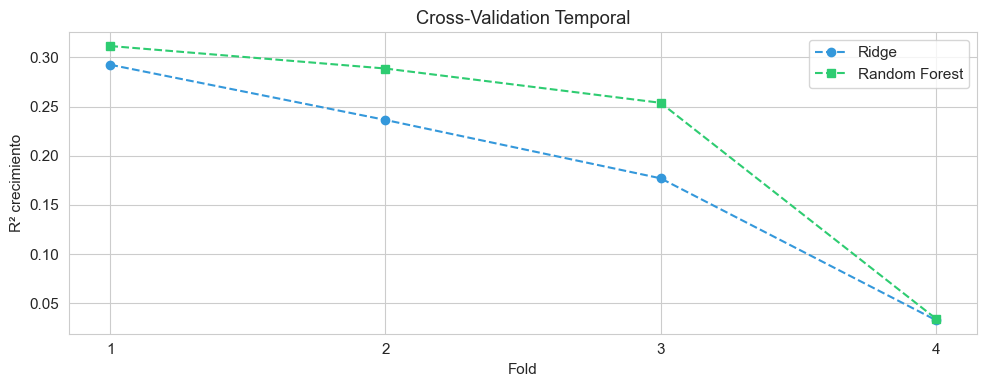

In [11]:
tscv = TimeSeriesSplit(n_splits=4)
cv_ridge = cross_val_score(Ridge(alpha=1.0), X_train_s, y_train, cv=tscv, scoring='r2', n_jobs=-1)
cv_rf = cross_val_score(RandomForestRegressor(n_estimators=200, max_depth=14, min_samples_leaf=20,
                        random_state=42, n_jobs=-1), X_train, y_train, cv=tscv, scoring='r2', n_jobs=-1)
print(f"CV temporal R²(crecimiento) — Ridge {cv_ridge.mean():.3f} | RF {cv_rf.mean():.3f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, 5), cv_ridge, 'o--', label='Ridge', color='#3498db')
ax.plot(range(1, 5), cv_rf, 's--', label='Random Forest', color='#2ecc71')
ax.set_xticks(range(1, 5)); ax.set_xlabel('Fold'); ax.set_ylabel('R² crecimiento')
ax.set_title('Cross-Validation Temporal'); ax.legend(); plt.tight_layout(); plt.show()

## 6. Modelos puntuales: Ridge → Random Forest → XGBoost

Todos predicen el crecimiento. La evaluación reconstruye el valor en euros y compara contra el
baseline ingenuo (el modelo vale la pena solo si lo supera).

In [12]:
def evaluar(nombre, modelo, X_tr, X_te):
    pgr_tr, pgr_te = modelo.predict(X_tr), modelo.predict(X_te)
    pred_level = np.log1p(valor_actual_test) + pgr_te
    pred_euros = np.clip(np.expm1(pred_level), 0, None)
    r = {'modelo': nombre,
         'r2_growth_train': r2_score(y_train, pgr_tr),
         'r2_growth_test': r2_score(y_test, pgr_te),
         'r2_level': r2_score(y_test_level, pred_level),
         'mae_euros': mean_absolute_error(mv_next_test, pred_euros),
         'rmse_euros': np.sqrt(mean_squared_error(mv_next_test, pred_euros)),
         'pred_euros': pred_euros, 'pred_growth': pgr_te}
    print(f"\n{'='*56}\n  {nombre}\n{'='*56}")
    print(f"  R² crecimiento  train {r['r2_growth_train']:.3f} | test {r['r2_growth_test']:.3f}")
    print(f"  R² nivel (test) {r['r2_level']:.4f}   (baseline {r2_base:.4f})")
    print(f"  MAE €{r['mae_euros']/1e6:.2f}M (baseline €{mae_base/1e6:.2f}M) | RMSE €{r['rmse_euros']/1e6:.2f}M")
    return r

In [13]:
ridge = Ridge(alpha=1.0); ridge.fit(X_train_s, y_train)
res_ridge = evaluar("Ridge", ridge, X_train_s, X_test_s)

rf = RandomForestRegressor(n_estimators=300, max_depth=14, min_samples_leaf=20, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
res_rf = evaluar("Random Forest", rf, X_train, X_test)

xgb_point = xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8,
                             colsample_bytree=0.8, random_state=42, tree_method='hist')
xgb_point.fit(X_train, y_train)
res_xgb = evaluar("XGBoost", xgb_point, X_train, X_test)


  Ridge
  R² crecimiento  train 0.231 | test 0.225
  R² nivel (test) 0.8669   (baseline 0.8247)
  MAE €0.88M (baseline €0.88M) | RMSE €3.34M



  Random Forest
  R² crecimiento  train 0.365 | test 0.284
  R² nivel (test) 0.8770   (baseline 0.8247)
  MAE €0.79M (baseline €0.88M) | RMSE €2.79M



  XGBoost
  R² crecimiento  train 0.375 | test 0.315
  R² nivel (test) 0.8824   (baseline 0.8247)
  MAE €0.75M (baseline €0.88M) | RMSE €2.58M


### 6.1 Comparación

          modelo  r2_growth_test  r2_level    mae_M
Baseline ingenuo        0.000000  0.824691 0.878546
           Ridge        0.225171  0.866896 0.878291
   Random Forest        0.284154  0.877028 0.789202
         XGBoost        0.315145  0.882352 0.745478

Mejor modelo puntual: XGBoost


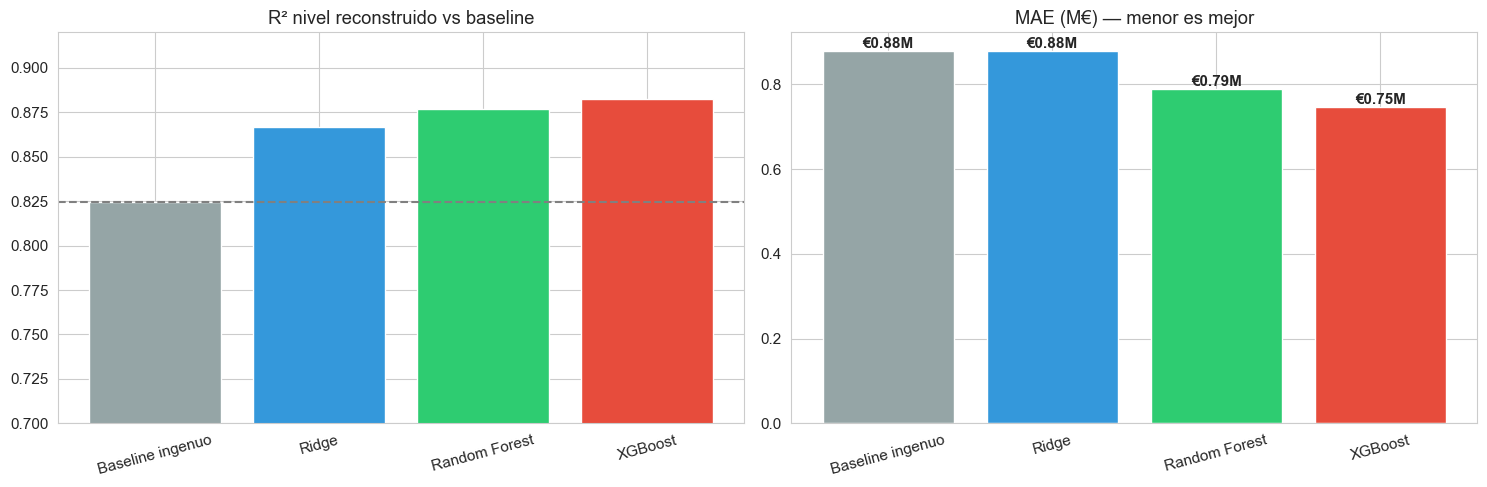

In [14]:
resultados = pd.DataFrame([
    {'modelo': 'Baseline ingenuo', 'r2_growth_test': 0.0, 'r2_level': r2_base, 'mae_euros': mae_base},
    *[{k: r[k] for k in ['modelo', 'r2_growth_test', 'r2_level', 'mae_euros']} for r in [res_ridge, res_rf, res_xgb]]])
resultados['mae_M'] = resultados['mae_euros'] / 1e6
print(resultados[['modelo', 'r2_growth_test', 'r2_level', 'mae_M']].to_string(index=False))

mejor = max([res_ridge, res_rf, res_xgb], key=lambda r: r['r2_level'])
modelo_mejor = {'Ridge': ridge, 'Random Forest': rf, 'XGBoost': xgb_point}[mejor['modelo']]
print(f"\nMejor modelo puntual: {mejor['modelo']}")

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
cols = ['#95a5a6', '#3498db', '#2ecc71', '#e74c3c']
ax[0].bar(resultados['modelo'], resultados['r2_level'], color=cols)
ax[0].axhline(r2_base, ls='--', color='gray'); ax[0].set_ylim(0.7, 0.92)
ax[0].set_title('R² nivel reconstruido vs baseline'); ax[0].tick_params(axis='x', rotation=15)
ax[1].bar(resultados['modelo'], resultados['mae_M'], color=cols)
ax[1].set_title('MAE (M€) — menor es mejor'); ax[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(resultados['mae_M']): ax[1].text(i, v, f'€{v:.2f}M', ha='center', va='bottom', fontweight='bold')
plt.tight_layout(); plt.show()

### 6.2 ¿Aprende a anticipar las caídas?

Sobre los **desaparecidos reales de 2023+** (jugadores que efectivamente perdieron seguimiento),
medimos qué fracción el modelo predice con crecimiento negativo (*recall de declives*). Un modelo
entrenado solo con supervivientes sería ciego a estos casos (recall = 0).

In [15]:
if len(des_test):
    Xdes = des_test[FEATURES].fillna(0)
    pg_des = modelo_mejor.predict(scaler.transform(Xdes) if mejor['modelo'] == 'Ridge' else Xdes)
    recall_declives = float((pg_des < 0).mean())
    print(f"Desaparecidos reales en test: {len(des_test)}")
    print(f"Recall de declives (predichos con crecimiento < 0): {recall_declives:.1%}")
    print(f"Crecimiento predicho medio para desaparecidos: {pg_des.mean():+.3f} (esperado: negativo)")
else:
    recall_declives = float('nan')
    print("No hay desaparecidos en el test.")

Desaparecidos reales en test: 11664
Recall de declives (predichos con crecimiento < 0): 45.5%
Crecimiento predicho medio para desaparecidos: +0.064 (esperado: negativo)


## 7. Error por segmento — ¿dónde acierta y dónde falla?

Un R² global esconde que el modelo no se equivoca igual en todos lados. Partimos el test por
tramo de valor, edad, liga y nivel de actividad para ver dónde es más confiable.

Por tramo de valor:
tramo_valor     n    MAE_M  valor_medio_M
        <1M 30387 0.224638       0.357472
       1-5M  7855 1.022609       2.491267
      5-20M  2638 3.242785      10.665201
       20M+   866 8.900208      41.166282

Por tramo de edad:
tramo_edad     n    MAE_M  valor_medio_M
       ≤21  8518 0.968732       1.459855
     22-25 12708 0.983281       2.776944
     26-29 10565 0.735953       3.071593
     30-33  6857 0.318827       1.784660
       34+  3098 0.132988       0.581979

Liga top-5 vs resto:
flag_liga_top
0    0.508
1    1.713


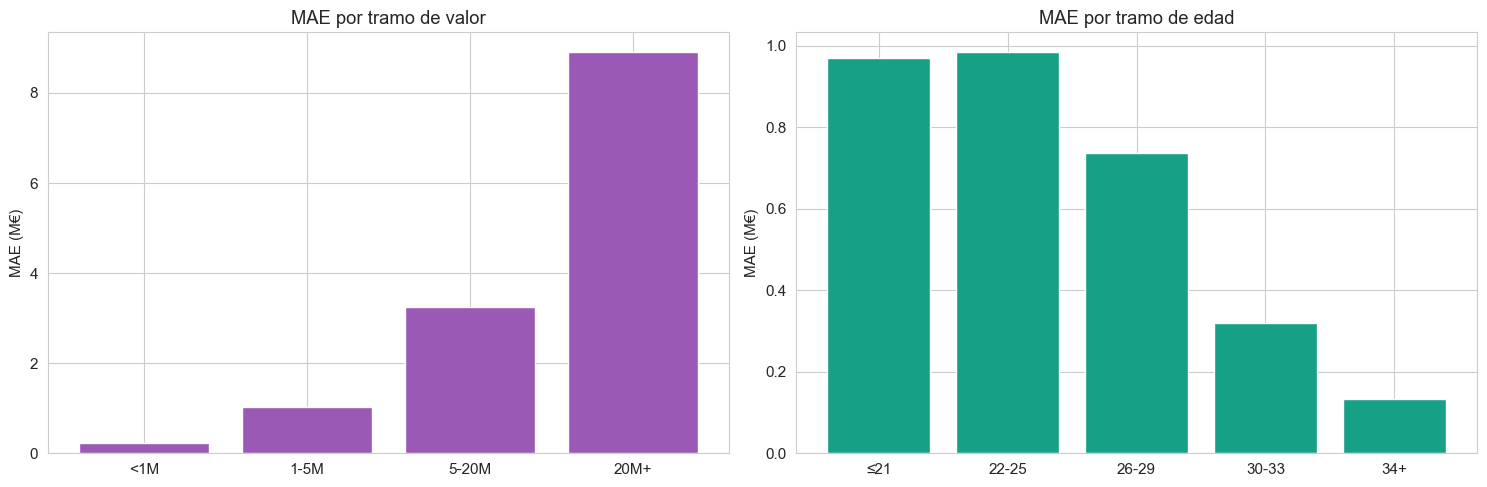

In [16]:
seg = test.copy()
seg['pred_euros'] = mejor['pred_euros']
seg['ae'] = (seg['pred_euros'] - seg['mv_next']).abs()
seg['tramo_valor'] = pd.cut(seg['valor'], [0, 1e6, 5e6, 20e6, 1e12],
                            labels=['<1M', '1-5M', '5-20M', '20M+'])
seg['tramo_edad'] = pd.cut(seg['edad'], [14, 21, 25, 29, 33, 46],
                           labels=['≤21', '22-25', '26-29', '30-33', '34+'])

def tabla_seg(col):
    g = seg.groupby(col).agg(n=('ae', 'size'), MAE_M=('ae', lambda s: s.mean() / 1e6),
                             valor_medio_M=('valor', lambda s: s.mean() / 1e6)).reset_index()
    return g

print("Por tramo de valor:"); print(tabla_seg('tramo_valor').to_string(index=False))
print("\nPor tramo de edad:"); print(tabla_seg('tramo_edad').to_string(index=False))
print("\nLiga top-5 vs resto:"); print(seg.groupby('flag_liga_top')['ae'].apply(lambda s: round(s.mean()/1e6, 3)).to_string())

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
tv = tabla_seg('tramo_valor'); ax[0].bar(tv['tramo_valor'].astype(str), tv['MAE_M'], color='#9b59b6')
ax[0].set_title('MAE por tramo de valor'); ax[0].set_ylabel('MAE (M€)')
ted = tabla_seg('tramo_edad'); ax[1].bar(ted['tramo_edad'].astype(str), ted['MAE_M'], color='#16a085')
ax[1].set_title('MAE por tramo de edad'); ax[1].set_ylabel('MAE (M€)')
plt.tight_layout(); plt.show()

## 8. Backtest rolling-origin

En vez de un único corte, reentrenamos avanzando el horizonte: entrenar con ≤ A-1 y testear en A,
para A = 2021, 2022, 2023, 2024. Da una **distribución** de performance, mucho más robusta que un
solo número.

In [17]:
backtest = []
for A in [2021, 2022, 2023, 2024]:
    tr = df[df['T'] <= A - 1].copy(); te = df[(df['T'] == A) & (df['desaparece'] == 0)].copy()
    for col in ['nivel_liga', 'nivel_club']:
        med = tr[col].median(); tr[col] = tr[col].fillna(med); te[col] = te[col].fillna(med)
    if len(te) < 50: continue
    m = xgb.XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8,
                         colsample_bytree=0.8, random_state=42, tree_method='hist')
    m.fit(tr[FEATURES].fillna(0), tr[TARGET])
    pl = np.log1p(te['valor'].values) + m.predict(te[FEATURES].fillna(0))
    pe = np.clip(np.expm1(pl), 0, None)
    base = r2_score(te['log_level'], np.log1p(te['valor'].values))
    backtest.append({'test_year': A, 'n': len(te), 'R2_level': r2_score(te['log_level'], pl),
                     'R2_baseline': base, 'MAE_M': mean_absolute_error(te['mv_next'], pe) / 1e6})
backtest = pd.DataFrame(backtest)
print(backtest.to_string(index=False))
print(f"\nR² nivel promedio: {backtest['R2_level'].mean():.4f} (baseline {backtest['R2_baseline'].mean():.4f}) "
      f"| MAE promedio €{backtest['MAE_M'].mean():.2f}M")

 test_year     n  R2_level  R2_baseline    MAE_M
      2021 22916  0.879249     0.822192 0.560104
      2022 23827  0.874305     0.810241 0.610314
      2023 24744  0.885717     0.829725 0.618678
      2024 17002  0.873896     0.808332 0.935095

R² nivel promedio: 0.8783 (baseline 0.8176) | MAE promedio €0.68M


## 9. Importancia de variables

Con el target de crecimiento la importancia se reparte: edad domina, pero contrato, contexto de
liga/club, inflación de mercado, transferencias y rendimiento aportan señal real.

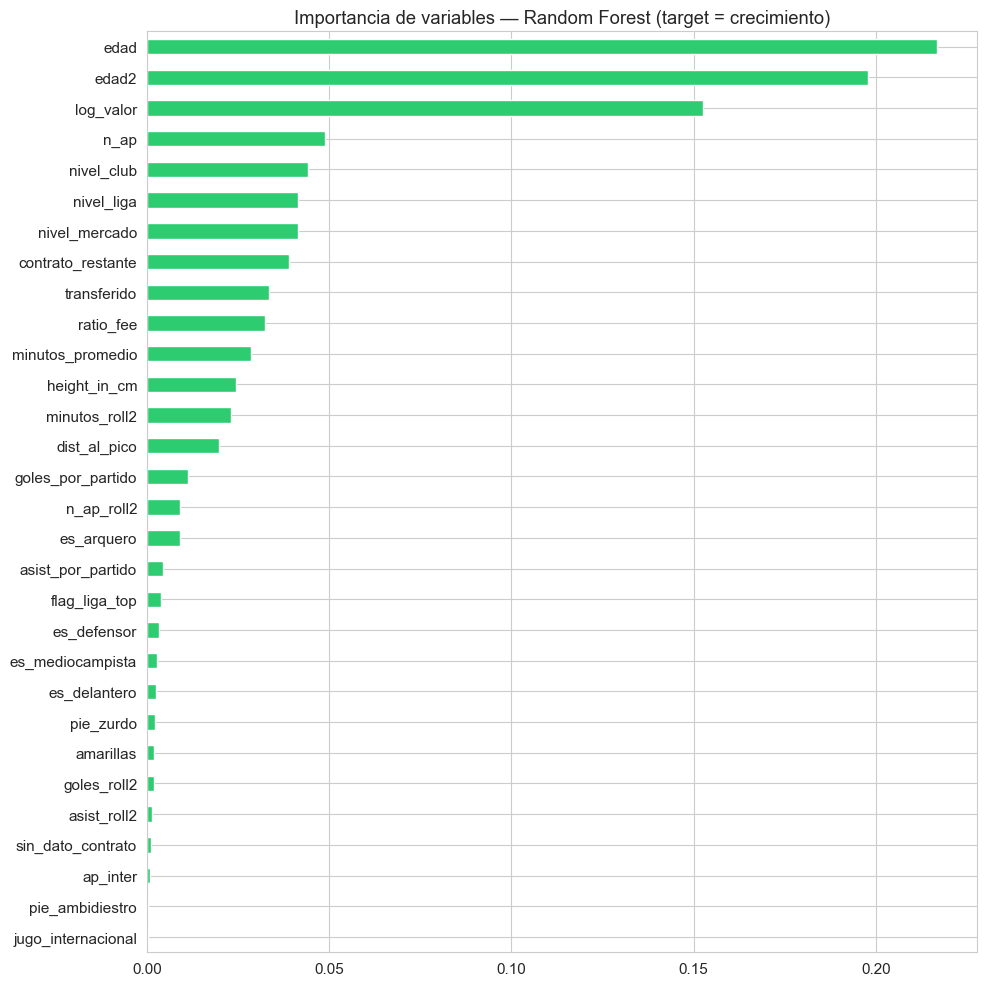

Top 12:
edad                 0.2169
edad2                0.1979
log_valor            0.1526
n_ap                 0.0488
nivel_club           0.0441
nivel_liga           0.0416
nivel_mercado        0.0413
contrato_restante    0.0391
transferido          0.0335
ratio_fee            0.0324
minutos_promedio     0.0286
height_in_cm         0.0245


In [18]:
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(10, 10))
imp.plot(kind='barh', ax=ax, color='#2ecc71')
ax.set_title('Importancia de variables — Random Forest (target = crecimiento)')
plt.tight_layout(); plt.show()
print('Top 12:'); print(imp.sort_values(ascending=False).head(12).round(4).to_string())

## 10. Intervalos de predicción calibrados (el producto para negociar)

Entrenamos XGBoost con **regresión cuantil** (P10, P50, P90) sobre el crecimiento. Los cuantiles
crudos suelen quedar mal calibrados (intervalos angostos), así que aplicamos **calibración
conformal (CQR)**: usamos un set de calibración para inflar el intervalo lo justo y necesario
para que la cobertura real ≈ 80%. Reportamos cobertura y ancho.

In [19]:
# Separar calibración del entrenamiento (sin tocar el test)
X_fit, X_cal, y_fit, y_cal = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
ALPHAS = np.array([0.1, 0.5, 0.9])
qmodel = xgb.XGBRegressor(objective='reg:quantileerror', quantile_alpha=ALPHAS,
                          n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8,
                          colsample_bytree=0.8, random_state=42, tree_method='hist')
qmodel.fit(X_fit, y_fit)

# CQR: score de no-conformidad sobre calibración y cuantil al 80%
q_cal = qmodel.predict(X_cal)
score = np.maximum(q_cal[:, 0] - y_cal.values, y_cal.values - q_cal[:, 2])
Q_CONF = np.quantile(score, 0.80)
print(f"Ajuste conformal Q = {Q_CONF:.4f} (en escala de crecimiento log)")

# Predicción en test con intervalo calibrado
q_te = qmodel.predict(X_test)
growth_lo, growth_med, growth_hi = q_te[:, 0] - Q_CONF, q_te[:, 1], q_te[:, 2] + Q_CONF
p10 = np.clip(np.expm1(np.log1p(valor_actual_test) + growth_lo), 0, None)
p50 = np.clip(np.expm1(np.log1p(valor_actual_test) + growth_med), 0, None)
p90 = np.clip(np.expm1(np.log1p(valor_actual_test) + growth_hi), 0, None)

cov_raw = ((mv_next_test >= np.expm1(np.log1p(valor_actual_test) + q_te[:, 0])) &
           (mv_next_test <= np.expm1(np.log1p(valor_actual_test) + q_te[:, 2]))).mean()
cov_cal = ((mv_next_test >= p10) & (mv_next_test <= p90)).mean()
print(f"Cobertura P10-P90 sin calibrar: {cov_raw:.1%} | calibrada: {cov_cal:.1%} (objetivo 80%)")
print(f"Ancho mediano del intervalo: €{np.median(p90 - p10)/1e6:.2f}M")
print(f"MAE de la mediana (P50): €{mean_absolute_error(mv_next_test, p50)/1e6:.2f}M")

Ajuste conformal Q = 0.0017 (en escala de crecimiento log)
Cobertura P10-P90 sin calibrar: 81.7% | calibrada: 82.1% (objetivo 80%)
Ancho mediano del intervalo: €0.57M
MAE de la mediana (P50): €0.75M


### 10.1 Ejemplos de intervalo

In [20]:
ej = test[['player_id', 'valor', 'mv_next']].copy()
ej['p10'], ej['p50'], ej['p90'] = p10, p50, p90
ej = ej.merge(players[['player_id', 'name']], on='player_id', how='left')
muestra = ej[ej['valor'] >= 10e6].sample(min(10, (ej['valor'] >= 10e6).sum()), random_state=1)
print("Ejemplos (jugadores de €10M+):")
for _, r in muestra.iterrows():
    dentro = '✓' if r['p10'] <= r['mv_next'] <= r['p90'] else '✗'
    print(f"  {str(r['name'])[:24]:24s} | rango €{r['p10']/1e6:5.1f}M – €{r['p90']/1e6:5.1f}M "
          f"(P50 €{r['p50']/1e6:5.1f}M) | real €{r['mv_next']/1e6:5.1f}M {dentro}")

Ejemplos (jugadores de €10M+):
  Valentin Rongier         | rango €  4.0M – €  9.6M (P50 €  6.5M) | real €  9.0M ✓
  Nathan Collins           | rango € 19.2M – € 34.5M (P50 € 23.3M) | real € 25.0M ✓
  Oleksandr Zinchenko      | rango € 21.1M – € 30.2M (P50 € 27.2M) | real € 20.0M ✗
  Levi García              | rango € 11.5M – € 21.6M (P50 € 15.1M) | real € 12.0M ✓
  Iñaki Williams           | rango € 16.9M – € 24.9M (P50 € 20.0M) | real € 15.0M ✗
  Jorrel Hato              | rango € 37.0M – € 67.4M (P50 € 41.4M) | real € 35.0M ✗
  Fabinho                  | rango € 17.1M – € 34.4M (P50 € 27.1M) | real € 25.0M ✓
  Kerem Aktürkoğlu         | rango € 14.3M – € 27.9M (P50 € 19.1M) | real € 24.0M ✓
  Zeno Debast              | rango €  8.2M – € 24.7M (P50 € 13.6M) | real € 18.0M ✓
  Aritz Elustondo          | rango €  5.3M – € 13.0M (P50 €  9.1M) | real €  5.0M ✗


## 11. Calibración del crecimiento

Agrupamos las predicciones de crecimiento en deciles y comparamos con el crecimiento realmente
observado. Si el modelo está bien calibrado, la curva sigue la diagonal.

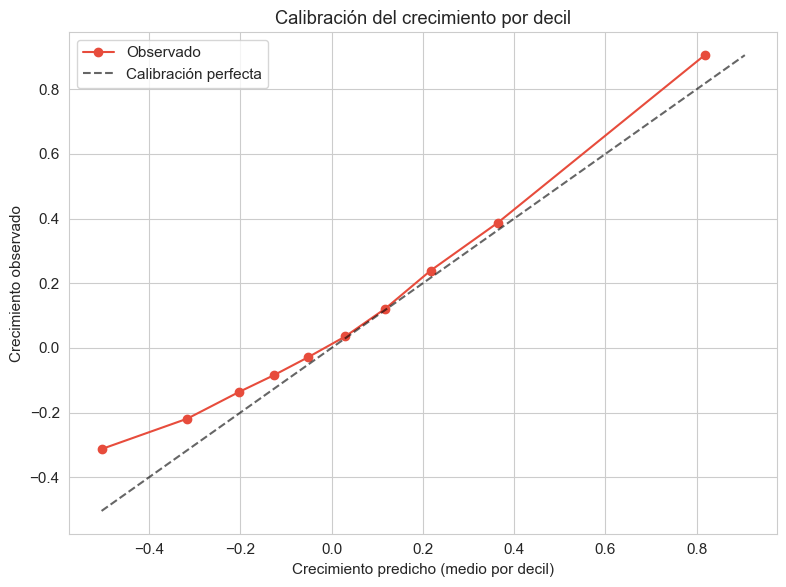

In [21]:
cal = pd.DataFrame({'pred': mejor['pred_growth'], 'real': y_test.values})
cal['decil'] = pd.qcut(cal['pred'], 10, labels=False, duplicates='drop')
curva = cal.groupby('decil').agg(pred=('pred', 'mean'), real=('real', 'mean')).reset_index()
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(curva['pred'], curva['real'], 'o-', color='#e74c3c', label='Observado')
lim = [curva[['pred', 'real']].min().min(), curva[['pred', 'real']].max().max()]
ax.plot(lim, lim, 'k--', alpha=0.6, label='Calibración perfecta')
ax.set_xlabel('Crecimiento predicho (medio por decil)'); ax.set_ylabel('Crecimiento observado')
ax.set_title('Calibración del crecimiento por decil'); ax.legend(); plt.tight_layout(); plt.show()

## 12. Aplicación de negocio: ranking de oportunidades con intervalo

Combinamos la dirección (crecimiento esperado) con la confianza (intervalo). Una **oportunidad
de alta confianza** es un jugador cuyo P10 ya supera su valor actual (el modelo proyecta suba
incluso en el escenario pesimista). El **riesgo** es el caso inverso.

In [22]:
rank = test[['player_id', 'valor', 'edad']].copy()
rank['p10'], rank['p50'], rank['p90'] = p10, p50, p90
rank['crec_pct'] = (rank['p50'] / rank['valor'] - 1) * 100
rank = rank.merge(players[['player_id', 'name', 'sub_position']], on='player_id', how='left')
rel = rank[rank['valor'] >= 5e6]

print("🟢 TOP 10 — revalorización con alta confianza (P10 > valor actual)")
alta = rel[rel['p10'] > rel['valor']].nlargest(10, 'crec_pct')
for _, r in alta.iterrows():
    print(f"  {str(r['name'])[:24]:24s} ({int(r['edad'])}a) | €{r['valor']/1e6:5.1f}M → "
          f"€{r['p50']/1e6:5.1f}M  [€{r['p10']/1e6:.0f}–{r['p90']/1e6:.0f}M] ({r['crec_pct']:+.0f}%)")

print("\n🔴 TOP 10 — riesgo de caída con alta confianza (P90 < valor actual)")
baja = rel[rel['p90'] < rel['valor']].nsmallest(10, 'crec_pct')
for _, r in baja.iterrows():
    print(f"  {str(r['name'])[:24]:24s} ({int(r['edad'])}a) | €{r['valor']/1e6:5.1f}M → "
          f"€{r['p50']/1e6:5.1f}M  [€{r['p10']/1e6:.0f}–{r['p90']/1e6:.0f}M] ({r['crec_pct']:+.0f}%)")

🟢 TOP 10 — revalorización con alta confianza (P10 > valor actual)
  Orri Óskarsson           (20a) | €  5.0M → € 20.3M  [€9–21M] (+305%)
  Carlos Baleba            (19a) | €  5.0M → € 18.6M  [€10–35M] (+271%)
  Omari Hutchinson         (21a) | €  7.0M → € 24.4M  [€12–30M] (+249%)
  Cole Palmer              (21a) | € 15.0M → € 45.9M  [€25–70M] (+206%)
  Álvaro Carreras          (21a) | €  7.0M → € 18.6M  [€10–22M] (+166%)
  Liam Delap               (21a) | €  8.0M → € 21.2M  [€14–31M] (+165%)
  Ernest Nuamah            (20a) | €  6.0M → € 15.9M  [€10–19M] (+165%)
  Dean Huijsen             (19a) | € 10.0M → € 25.5M  [€13–36M] (+155%)
  Jorrel Hato              (17a) | €  5.0M → € 12.5M  [€5–34M] (+151%)
  Johan Bakayoko           (20a) | € 10.0M → € 24.5M  [€12–37M] (+145%)

🔴 TOP 10 — riesgo de caída con alta confianza (P90 < valor actual)
  Roberto Firmino          (32a) | € 18.0M → €  7.0M  [€5–13M] (-61%)
  Andy Delort              (32a) | €  7.0M → €  2.7M  [€2–4M] (-61%)
  Kieran 

## 13. Persistencia del modelo

Guardamos el modelo cuantil (que produce los intervalos), el modelo puntual, el scaler y la
metadata —incluyendo el ajuste conformal y la variante de caída elegida— en `modelos/`. La ruta
es relativa al repositorio, así que **los profesores pueden cargar y predecir sin reentrenar**,
en Colab o en local.

In [23]:
MODELO_PATH = Path(DATA_PATH).resolve().parent.parent / 'modelos'
MODELO_PATH.mkdir(parents=True, exist_ok=True)
for viejo in MODELO_PATH.glob('*.joblib'):   # limpiar artefactos de corridas anteriores
    viejo.unlink()
joblib.dump(qmodel, MODELO_PATH / 'xgboost_cuantil.joblib')
joblib.dump(modelo_mejor, MODELO_PATH / 'modelo_puntual.joblib')
joblib.dump(scaler, MODELO_PATH / 'standard_scaler.joblib')

metadata = {
    'features': FEATURES, 'target': TARGET,
    'descripcion_target': 'log1p(valor_T+1) - log1p(valor_T) (crecimiento logarítmico a 12 meses, anclado al 30/06)',
    'reconstruccion': 'valor_pred = expm1(log1p(valor_actual) + crecimiento_pred)',
    'cuantiles': ALPHAS.tolist(), 'ajuste_conformal_Q': float(Q_CONF),
    'intervalo': 'P10 = expm1(log1p(valor)+q10-Q) ; P90 = expm1(log1p(valor)+q90+Q)',
    'devaluacion_desaparecidos': None if DEVALUACION is None else float(DEVALUACION),
    'mejor_modelo_puntual': mejor['modelo'],
    'metricas_test': {'r2_level': round(mejor['r2_level'], 4), 'r2_level_baseline': round(r2_base, 4),
                      'mae_euros': round(mejor['mae_euros'], 2), 'cobertura_intervalo': round(float(cov_cal), 4),
                      'recall_declives': round(recall_declives, 4),
                      'r2_level_backtest_medio': round(float(backtest['R2_level'].mean()), 4)},
    'split': {'train': 'T <= 2022', 'test': 'T >= 2023'},
}
with open(MODELO_PATH / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print('Guardado en', MODELO_PATH)
for p in sorted(MODELO_PATH.glob('*')): print('  -', p.name)

Guardado en C:\Users\argon\Desktop\ciencia de datos\futbol-valuacion\modelos
  - metadata.json
  - modelo_puntual.joblib
  - standard_scaler.joblib
  - xgboost_cuantil.joblib


### 13.1 Verificación: recargar y predecir un intervalo sin reentrenar

In [24]:
qm = joblib.load(MODELO_PATH / 'xgboost_cuantil.joblib')
meta = json.load(open(MODELO_PATH / 'metadata.json', encoding='utf-8'))
fila = X_test.iloc[[0]][meta['features']]
v0 = float(test['valor'].iloc[0]); Q = meta['ajuste_conformal_Q']
qq = qm.predict(fila)[0]
lo = np.expm1(np.log1p(v0) + qq[0] - Q); md = np.expm1(np.log1p(v0) + qq[1]); hi = np.expm1(np.log1p(v0) + qq[2] + Q)
print(f"Modelo recargado: {meta['mejor_modelo_puntual']} + cuantil")
print(f"Jugador ejemplo — valor actual €{v0/1e6:.2f}M")
print(f"Predicción a 12 meses: €{md/1e6:.2f}M  | intervalo €{lo/1e6:.2f}M – €{hi/1e6:.2f}M")
print(f"Valor real T+1: €{test['mv_next'].iloc[0]/1e6:.2f}M")

Modelo recargado: XGBoost + cuantil
Jugador ejemplo — valor actual €0.25M
Predicción a 12 meses: €0.15M  | intervalo €0.11M – €0.26M
Valor real T+1: €0.25M


## 14. Reflexión final

### Enfoque y justificación
Predecimos el **crecimiento** del valor a 12 meses (anclado al cierre de temporada), no el nivel.
Esto evita que el modelo se limite a copiar el valor actual y lo obliga a aprender de edad,
rendimiento, liga, club, contrato, transferencias e inflación del mercado. El producto es un
**intervalo calibrado** (~80% de cobertura) más un **ranking de oportunidades**, pensado para
apoyar decisiones de fichaje y negociación.

### Cómo leer los resultados
- **R²(crecimiento)** es modesto a propósito: predecir el cambio es difícil y ruidoso. Es la
  métrica honesta del problema.
- **R²(nivel) y MAE** se comparan contra el **baseline ingenuo** (T+1=T). Superarlo demuestra que
  las variables aportan por encima de la simple persistencia.
- **Cobertura del intervalo**: gracias a la calibración conformal, el rango P10–P90 contiene al
  valor real ≈ 80% de las veces.
- El **backtest rolling-origin** confirma que el resultado es estable across años, no un golpe de
  suerte de un único corte.

### Mejoras incorporadas respecto a la versión anterior
1. **Horizonte anclado a 12 meses** (antes el gap variaba entre 6 y 18 meses).
2. **Sesgo de supervivencia corregido**: el modelo ahora aprende también las caídas de jugadores
   que desaparecen (se eligió la intensidad de caída empíricamente, sección 3.7).
3. **Features nuevas con peso real**: contrato restante, actividad de transferencias, rendimiento
   rolling de 2 años, distancia al pico histórico, inflación de mercado, altura y pie.
4. **Intervalos de predicción calibrados** (regresión cuantil + conformal) en vez de un único número.
5. **Validación robusta**: backtest rolling-origin, métricas por segmento y curva de calibración.

### Limitaciones
- El target son **valuaciones editoriales** de Transfermarkt, no precios reales de transferencia.
- El valor asignado a los **desaparecidos** es un supuesto (caída a una fracción del valor); se
  eligió por validación, pero sigue siendo una aproximación.
- El rendimiento de **selección nacional** casi no figura en los datos; "internacional" se limita
  a competiciones continentales de clubes.
- No se modelan lesiones puntuales ni cláusulas contractuales más allá de la fecha de vencimiento.

### Próximos pasos (Entregable 4)
- Interfaz para consultar el intervalo de un jugador dado su perfil.
- SHAP para explicar predicciones individuales.
- Validación contra fees reales de `transfers.csv`.
- Los modelos ya quedan persistidos en `modelos/` y se cargan sin reentrenar (sección 13).